# Week 2: Inference and Sampling

Runs as-is on a small local model so you can see each stage; cells marked **TODO (you)** are where you do the work. No GPU, no API key. Dependencies: `transformers`, `torch` (CPU), `numpy`, `matplotlib`.

Parts: trace the forward pass, build the sampling explorer, evaluate three settings, find one failure, submit.

In [1]:
# Setup. In Colab: !pip install transformers torch numpy matplotlib
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import pathlib
os.environ['HF_HOME'] = str((pathlib.Path('.') / '.hf_cache').resolve())
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
torch.manual_seed(0)
name = 'distilgpt2'
tok = AutoTokenizer.from_pretrained(name)
model = AutoModelForCausalLM.from_pretrained(name, attn_implementation='eager')  # eager so attention is returned
model.eval()
cfg = model.config
print(f'{name}: {cfg.n_layer} layers, {cfg.n_head} heads, embed dim {cfg.n_embd}, vocab {cfg.vocab_size}')

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

distilgpt2: 6 layers, 12 heads, embed dim 768, vocab 50257


## Part 1: Trace the forward pass
**TODO (you):** change the prompt to your own. Read off the real numbers at each stage.

In [2]:
prompt = 'The diabetes app will provide a customizable notification engine'
enc = tok(prompt, return_tensors='pt')
ids = enc['input_ids'][0]
print('token IDs:', ids.tolist())
for i, t in enumerate(ids.tolist()):
    print(f'  pos {i}: id {t:6d} -> {tok.decode([t])!r}')

emb = model.transformer.wte(ids)
print('\nembedded prompt shape (seq_len, dim):', tuple(emb.shape))

with torch.no_grad():
    out = model(**enc, output_attentions=True)
att = out.attentions[0][0, 0, -1]   # layer 0, head 0, last token attends to...
print('last-token attention (layer 0, head 0), sums to', round(att.sum().item(), 4))
for j in range(ids.shape[0]):
    print(f'  {tok.decode([ids[j]])!r:12s} {att[j].item():.3f}')

with torch.no_grad():
    logits = model(**enc).logits
print('\nlogits shape (batch, seq, vocab):', tuple(logits.shape))
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 10)
print('top 10 next tokens:')
for p, idx in zip(top.values.tolist(), top.indices.tolist()):
    print(f'  {tok.decode([idx])!r:14s} {p:.4f}')
next_logits = logits[0, -1]

token IDs: [464, 12593, 598, 481, 2148, 257, 38322, 14483, 3113]
  pos 0: id    464 -> 'The'
  pos 1: id  12593 -> ' diabetes'
  pos 2: id    598 -> ' app'
  pos 3: id    481 -> ' will'
  pos 4: id   2148 -> ' provide'
  pos 5: id    257 -> ' a'
  pos 6: id  38322 -> ' customizable'
  pos 7: id  14483 -> ' notification'
  pos 8: id   3113 -> ' engine'

embedded prompt shape (seq_len, dim): (9, 768)
last-token attention (layer 0, head 0), sums to 1.0
  'The'        0.199
  ' diabetes'  0.112
  ' app'       0.163
  ' will'      0.063
  ' provide'   0.043
  ' a'         0.044
  ' customizable' 0.175
  ' notification' 0.048
  ' engine'    0.151

logits shape (batch, seq, vocab): (1, 9, 50257)
top 10 next tokens:
  ' that'        0.2274
  ' for'         0.1812
  ' to'          0.1475
  ','            0.0807
  ' with'        0.0642
  '.'            0.0610
  ' and'         0.0336
  ' which'       0.0196
  ' so'          0.0135
  ' based'       0.0124


## Part 2: Build the sampling explorer
Temperature, top-k, and top-p over the model's real next-token distribution.

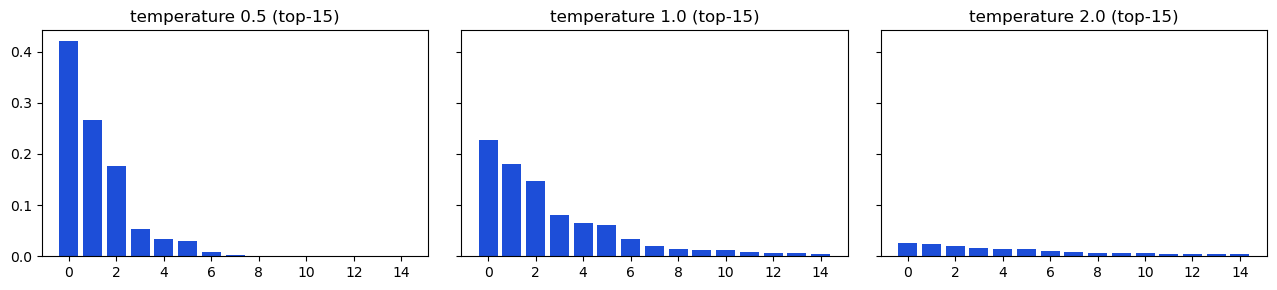

top token prob: temp 0.5 = 0.421, temp 1.0 = 0.227, temp 2.0 = 0.026


In [3]:
import numpy as np, matplotlib.pyplot as plt
z = next_logits.detach().numpy()

def softmax(x):
    x = x - x.max(); e = np.exp(x); return e / e.sum()
def temperature(z, t):
    return softmax(z / t)
def top_k(p, k):
    out = np.zeros_like(p); idx = np.argsort(p)[::-1][:k]; out[idx] = p[idx]; return out / out.sum()
def top_p(p, thresh):
    order = np.argsort(p)[::-1]; cdf = np.cumsum(p[order]); cut = np.searchsorted(cdf, thresh) + 1
    out = np.zeros_like(p); out[order[:cut]] = p[order[:cut]]; return out / out.sum(), cut

base = softmax(z)
fig, axes = plt.subplots(1, 3, figsize=(13, 3), sharey=True)
for ax, t in zip(axes, [0.5, 1.0, 2.0]):
    pt = temperature(z, t)
    ax.bar(range(15), np.sort(pt)[::-1][:15], color='#1d4ed8')
    ax.set_title(f'temperature {t} (top-15)')
plt.tight_layout(); plt.show()
print('top token prob: temp 0.5 = %.3f, temp 1.0 = %.3f, temp 2.0 = %.3f' % (
    temperature(z,0.5).max(), temperature(z,1.0).max(), temperature(z,2.0).max()))

## Part 3: Evaluate three settings with real figures
Predict first, then read the entropy, the maximum probability, and how many tokens survive.

In [4]:
def entropy(p):
    p = p[p > 0]; return float(-(p * np.log(p)).sum())
for t, tp in [(1e-6, 1.0), (0.7, 1.0), (1.3, 0.9)]:
    p = temperature(z, t)
    _, kept = top_p(p, tp)
    print(f'temp {t:<6} top-p {tp}: entropy {entropy(p):.3f}, max prob {p.max():.3f}, nucleus keeps {kept} tokens')

temp 1e-06  top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7    top-p 1.0: entropy 1.921, max prob 0.331, nucleus keeps 50258 tokens
temp 1.3    top-p 0.9: entropy 4.592, max prob 0.137, nucleus keeps 448 tokens


**Predictions (before running):**

Row 1 (temp 1e-6, top-p 1.0): near-zero temp should basically break the distribution. One token eats almost all the probability, so I'm expecting max prob close to 1 and entropy near 0. Top-p at 1.0 shouldn't filter anything, so I figured all 50257 tokens survive.

Row 2 (temp 0.7, top-p 1.0): a smaller version of what I already saw in Part 2. Temp 0.5 pushed max prob to 0.421, so 0.7 should land somewhere below that, maybe low 0.3s. Same assumption on top-p=1.0 keeping the full vocab.

Row 3 (temp 1.3, top-p 0.9): flips direction since temp above 1 spreads things out. Max prob should drop below the 0.227 baseline and entropy should climb. No real guess on how many tokens the 0.9 cutoff keeps once the distribution is flatter, that one felt impossible to eyeball.

**Actual results:**

temp 1e-06 top-p 1.0: entropy -0.000, max prob 1.000, nucleus keeps 1 tokens
temp 0.7 top-p 1.0: entropy 1.921, max prob 0.331, nucleus keeps 50258 tokens
temp 1.3 top-p 0.9: entropy 4.592, max prob 0.137, nucleus keeps 448 tokens

**Comparison:**

Row 1 nailed the entropy and max prob, but "1 token kept" caught me off guard. I'd assumed top-p=1.0 always means keep everything, but that's not actually what the code does. It adds tokens until the cumulative probability crosses 1.0, and once temperature collapses the distribution onto one token, that happens immediately. So top-p=1.0 isn't a fixed no-filtering setting, it just depends on how peaked things already are.

Row 2's max prob (0.331) was right where I guessed. But 50258 tokens kept is flat-out wrong since there are only 50257 tokens in the vocab. That's not a sampling quirk, it's a bug: floating-point rounding means the probabilities never sum to exactly 1.0, so the cutoff index ends up one past the array's end.

Row 3 was the one I got closest on across the board. 0.137 vs. my 0.15-0.18 guess, entropy went up like I expected, and 448 tokens is a reasonable number for what survives a 90% cutoff once the distribution's been flattened out.

## Part 4: Failure Case

In [5]:
# My failure case: top-p=1.0 doesn't always keep the full vocab
# This uses the row 1 and row 2 results from Part 3 above (temp=1e-6 and temp=0.7,
# both with top-p=1.0), showing that "tokens kept" depends on how peaked the
# distribution already is, not just the top-p value itself.

for t in [1e-6, 0.7, 1.3, 2.0]:
    p = temperature(z, t)
    _, kept = top_p(p, 1.0)
    print(f'temp {t:<6} top-p 1.0: max prob {p.max():.4f}, nucleus keeps {kept} tokens')

temp 1e-06  top-p 1.0: max prob 1.0000, nucleus keeps 1 tokens
temp 0.7    top-p 1.0: max prob 0.3306, nucleus keeps 50258 tokens
temp 1.3    top-p 1.0: max prob 0.1368, nucleus keeps 50258 tokens
temp 2.0    top-p 1.0: max prob 0.0259, nucleus keeps 50151 tokens


**Failure case: top-p = 1.0 doesn't reliably keep the whole vocab**

Going in, I assumed top-p=1.0 was basically a no-op, a setting that turns nucleus filtering off. That's not what the code does. Top-p works by sorting tokens by probability, then adding them one at a time until the cumulative probability crosses the threshold. At threshold 1.0, that should mean adding every single token, since the full distribution always sums to 1.0.

But at temp=1e-6, only 1 token gets kept even with top-p=1.0. Once temperature collapses the distribution so hard that one token holds almost 100% of the probability, the cumulative sum crosses 1.0 after that single token, so the loop stops there. The behavior is correct given the code, but it breaks the assumption that top-p=1.0 is a stable keep-everything setting. It isn't. It depends entirely on how peaked the distribution already is.

Cause: top-p is defined relative to cumulative probability, not vocab size. A peaked enough distribution can satisfy the 1.0 threshold with very few tokens.

Mitigation: don't treat top-p=1.0 as equivalent to disabling nucleus filtering. If the goal is actually no filtering, skip calling top_p entirely instead of passing threshold=1.0, since the two aren't the same thing once temperature has already reshaped the distribution.

**Related bug worth flagging separately:** at temp=0.7, top-p=1.0, the same cell reported 50258 tokens kept, one more than the actual vocab size of 50257. That's not a sampling behavior, I beleive it's a floating point rounding bug. The cumulative probabilities across the full array never sum to exactly 1.0, so np.searchsorted returns an index one past the end of the array, and the plus one in the cutoff calculation pushes it further. NumPy slicing tolerates the out of bounds index instead of erroring, so it doesn't crash, it just prints a wrong number. It could be worth a one line fix in production code, clipping the cut value to len(p), but I'm noting it here instead of fixing it since it's a good example of how an off by one can hide in code that runs fine.